<a href="https://colab.research.google.com/github/Liex2810/FAKTAalone/blob/main/Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧹 Processing Notebook

Tahap processing sebelum data masuk ke model LSTM.

In [2]:
import re
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [5]:
df = pd.read_csv("alternativedataset.csv")
df.head()

,text,label
0,ternyata ini kodenya pantesan tetangga gak per...,hoax
1,purbaya yudhi sadewa butuh dana bantuan tenang...,hoax
2,memanas guys menkeu purbaya tantang luhut menk...,hoax
3,megawati soekarnoputri ingatkan kalo mau lihat...,hoax
4,silahkan hubungi whatsap untuk mendaftar 08584...,hoax


In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_text"]=df["text"].apply(clean_text)
df[["text","clean_text"]].head()

,text,clean_text
0,ternyata ini kodenya pantesan tetangga gak per...,ternyata ini kodenya pantesan tetangga gak per...
1,purbaya yudhi sadewa butuh dana bantuan tenang...,purbaya yudhi sadewa butuh dana bantuan tenang...
2,memanas guys menkeu purbaya tantang luhut menk...,memanas guys menkeu purbaya tantang luhut menk...
3,megawati soekarnoputri ingatkan kalo mau lihat...,megawati soekarnoputri ingatkan kalo mau lihat...
4,silahkan hubungi whatsap untuk mendaftar 08584...,silahkan hubungi whatsap untuk mendaftar 08584...


In [7]:
slang_dict={"gak":"tidak","ga":"tidak","udah":"sudah","yg":"yang","dgn":"dengan"}

def normalize_slang(text):
    return " ".join(slang_dict.get(w,w) for w in text.split())

df["normalized_text"]=df["clean_text"].apply(normalize_slang)
df[["clean_text","normalized_text"]].head()

,clean_text,normalized_text
0,ternyata ini kodenya pantesan tetangga gak per...,ternyata ini kodenya pantesan tetangga tidak p...
1,purbaya yudhi sadewa butuh dana bantuan tenang...,purbaya yudhi sadewa butuh dana bantuan tenang...
2,memanas guys menkeu purbaya tantang luhut menk...,memanas guys menkeu purbaya tantang luhut menk...
3,megawati soekarnoputri ingatkan kalo mau lihat...,megawati soekarnoputri ingatkan kalo mau lihat...
4,silahkan hubungi whatsap untuk mendaftar 08584...,silahkan hubungi whatsap untuk mendaftar 08584...


In [8]:
df["word_count"]=df["normalized_text"].str.split().str.len()
df["char_count"]=df["normalized_text"].str.len()
df[["normalized_text","word_count","char_count"]].head()

,normalized_text,word_count,char_count
0,ternyata ini kodenya pantesan tetangga tidak p...,14,94
1,purbaya yudhi sadewa butuh dana bantuan tenang...,44,313
2,memanas guys menkeu purbaya tantang luhut menk...,54,353
3,megawati soekarnoputri ingatkan kalo mau lihat...,24,176
4,silahkan hubungi whatsap untuk mendaftar 08584...,58,433


In [11]:
tokenizer=Tokenizer(num_words=10000,oov_token="<OOV>")
tokenizer.fit_on_texts(df["normalized_text"])
sequences=tokenizer.texts_to_sequences(df["normalized_text"])
print(sequences[0])

# Mengambil kamus pemetaan dari angka ke kata
index_to_word = tokenizer.index_word

# Melihat kata untuk setiap indeks yang ada di kalimat pertama
for index in sequences[0]:
    word = index_to_word.get(index, "<OOV>")
    # Format :<5d artinya memberi jarak/spasi konstan sebesar 5 karakter agar rapi
    print(f"Indeks {index:<5d} -> {word}")

[419, 5, 1, 9728, 2594, 11, 428, 944, 969, 91, 32, 209, 4389, 369]
Indeks 419   -> ternyata
Indeks 5     -> ini
Indeks 1     -> <OOV>
Indeks 9728  -> pantesan
Indeks 2594  -> tetangga
Indeks 11    -> tidak
Indeks 428   -> pernah
Indeks 944   -> isi
Indeks 969   -> token
Indeks 91    -> gratis
Indeks 32    -> 3
Indeks 209   -> bulan
Indeks 4389  -> pemakaian
Indeks 369   -> listrik


In [12]:
X=pad_sequences(sequences,maxlen=150,padding="post",truncating="post")
print(X.shape)
print(X[0])

# Mengambil kamus pemetaan dari angka ke kata
index_to_word = tokenizer.index_word

# Melihat kata/padding untuk setiap indeks hasil padding di kalimat pertama
for index in X[0]:
    # Jika angka 0, berarti itu adalah padding tambahan
    if index == 0:
        word = "<PADDING>"
    else:
        word = index_to_word.get(index, "<OOV>")

    print(f"Indeks {index:<5d} -> {word}")

(7738, 150)
[ 419    5    1 9728 2594   11  428  944  969   91   32  209 4389  369
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0]
Indeks 419   -> ternyata
Indeks 5     -> ini
Indeks 1     -> <OOV>
Indeks 9728  -> pantesan
Indeks 2594  -> tetangga
Indeks 11    -> tidak
Indeks 428   -> pernah
Indeks 944   -> isi
Indeks 969   -> token
Indeks 91    -> gratis

## Output

Processing selesai.

- Text Cleaning
- Slang Normalization
- Feature Extraction
- Tokenization
- Text to Sequence
- Padding

Variabel **X** siap digunakan sebagai input Bidirectional LSTM.

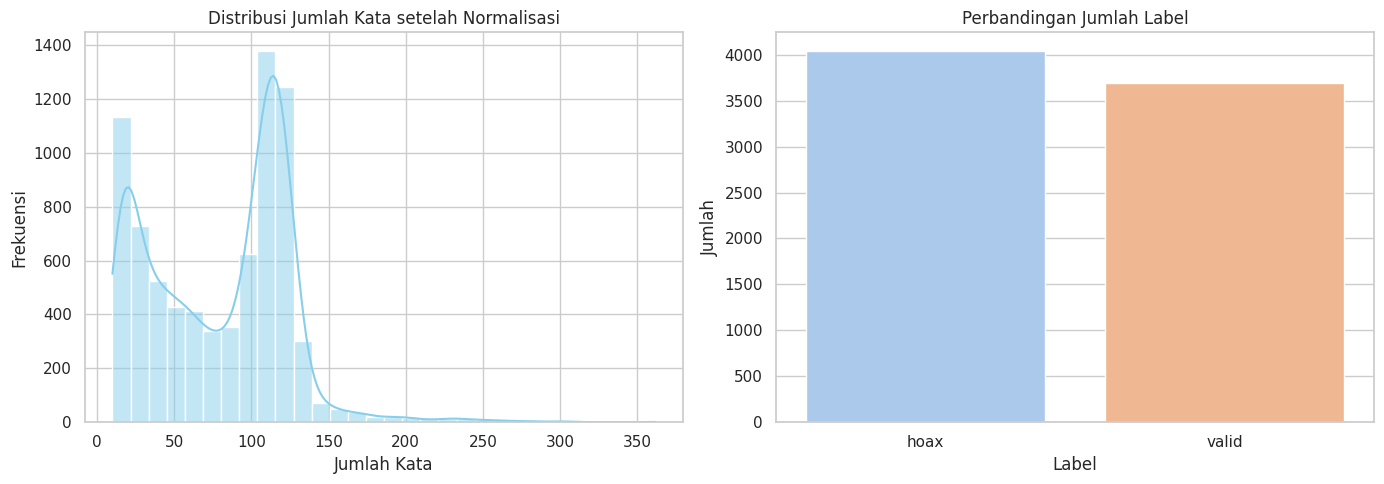

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Visualisasi Distribusi Jumlah Kata
sns.histplot(df['word_count'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Jumlah Kata setelah Normalisasi')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')

# 2. Visualisasi Perbandingan Label (Hoax vs Valid)
sns.countplot(x='label', data=df, ax=axes[1], palette='pastel', hue='label', legend=False)
axes[1].set_title('Perbandingan Jumlah Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

In [14]:
from google.colab import files

# 1. Simpan DataFrame ke dalam file CSV di session storage Colab
df.to_csv('dataset_hasil_processing.csv', index=False)

# 2. Download langsung file tersebut ke komputer Anda
files.download('dataset_hasil_processing.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>